# TFT(Temporal Fusion Transformer) - deep learning 
Arquitectura implementada: 
- LSTM encoder para procesar la secuencia temporal
- Multi-Head Attention sobre todos los estados del encoder.
- Gated Residual Network para filtrar información relevante
- Capa fully-connected para la predicción final

# Importaciones y configuraciones

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Paths
DATA_PATH = Path.cwd().parent / "data"
RESULTS_PATH = Path.cwd().parent / "results"

# Activos
ACTIVOS = ["eurusd", "gbpusd", "usdjpy", "btc", "eth"]

print(f"PyTorch version: {torch.__version__}")
print("Datos disponibles:")
for a in ACTIVOS:
    df = pd.read_csv(DATA_PATH / f"{a}_processed.csv", index_col=0)
    print(f" {a.upper()}: {len(df)} filas")

PyTorch version: 2.10.0+cpu
Datos disponibles:
 EURUSD: 2145 filas
 GBPUSD: 2145 filas
 USDJPY: 2145 filas
 BTC: 3011 filas
 ETH: 3011 filas


# Arquitectura TFT

In [2]:
# -- Gated Residual Network (GRN) --------------------------------
class GRN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.1):
        super(GRN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.gate = nn.Linear(input_size, output_size)
        self.norm = nn.LayerNorm(output_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x if x.shape[-1] == self.fc2.out_features else None
        h = F.elu(self.fc1(x))
        h = self.dropout(self.fc2(h))
        g = torch.sigmoid(self.gate(x))
        out = self.norm(g * h + (1 - g) * (x if residual is None else x[..., :h.shape[-1]]))
        return out

# -- Modelo TFT simplificado -------------------------------------------------
class TFTModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_heads=4,
                 num_layers=2, dropout=0.1):
        super(TFTModel, self).__init__()
        
        # LSTM encoder
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )        
        
        # Multi-Head Attention temporal
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        
        # Gated Residual Network
        self.grn = GRN(hidden_size, hidden_size * 2, hidden_size, dropout)
        
        # Capa de salida
        self.fc_out = nn.Linear(hidden_size, 1)
        self.norm = nn.LayerNorm(hidden_size)
        
    def forward(self, x):
        # LSTM encoder -> todos los estados
        lstm_out, _ = self.lstm(x)
        
        # Atención temporal: query = último estado, key/value = todos los estados
        query = lstm_out[:, -1:, :]
        attn_out, _ = self.attention(query, lstm_out, lstm_out)
        attn_out = attn_out.squeeze(1)
        
        # GRN + normalización
        out = self.grn(attn_out)
        out = self.norm(out)
        
        return self.fc_out(out)
    
# -- Función: crear secuencias -------------------------------------------
def crear_secuencias(serie, window=20):
    X, y = [], []
    for i in range(len(serie) - window):
        X.append(serie[i:i+window])
        y.append(serie[i+window])
    return np.array(X), np.array(y)

# -- Función: entrenar y evaluar un activo -------------------------------
def entrenar_tft(nombre, window=20, epochs=50, batch_size=32):
    # Cargar datos
    df = pd.read_csv(DATA_PATH / f"{nombre}_processed.csv", index_col=0, parse_dates=True)
    retornos = df["Retorno"].dropna().values.reshape(-1, 1)
    regimen = df["Regimen"].dropna().values
    
    # Escalar
    scaler = StandardScaler()
    retornos_scaled = scaler.fit_transform(retornos).flatten()
    
    # Secuencias
    X, y = crear_secuencias(retornos_scaled, window)
    
    # Split 80/20 temporal
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    
    # Alinear  régimen
    regimen_y = regimen[window:]
    reg_test = regimen_y[split:split + len(y_test)]
    
    # Tensores
    X_train_t   = torch.FloatTensor(X_train).unsqueeze(-1)
    y_train_t   = torch.FloatTensor(y_train).unsqueeze(-1)
    X_test_tensor = torch.FloatTensor(X_test).unsqueeze(-1)
    
    # DataLoader
    dataset = TensorDataset(X_train_t, y_train_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    # Modelo
    model       = TFTModel()
    criterion   = nn.MSELoss()
    optimizer   = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Entrenamiento
    model.train()
    for epoch in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    
    # Predicción
    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_test_tensor).squeeze().numpy()
    
    # Desescalar
    preds = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    # Forzar mismo tamaño
    n       = min(len(preds), len(actual), len(reg_test))
    preds   = preds[:n]
    actual  = actual[:n]
    reg_test = reg_test[:n]
    
    # Métricas globales
    mae = np.mean(np.abs(preds - actual))
    rmse = np.sqrt(np.mean((preds - actual)**2))
    
    # Métricas por régimen
    mask_alta = reg_test == "Alta"
    mask_baja = reg_test == "Baja"
    mae_baja = np.mean(np.abs(preds[mask_baja] - actual[mask_baja])) if mask_baja.any() else np.nan
    mae_alta = np.mean(np.abs(preds[mask_alta] - actual[mask_alta])) if mask_alta.any() else np.nan

    print(f"{nombre.upper():8s} | MAE={mae:.6f} | RMSE={rmse:.6f} | MAE_baja={mae_baja:.6f} | MAE_alta={mae_alta:.6f}")
    return {
        "Activo": nombre.upper(), "MAE": mae, "RMSE": rmse,
        "MAE_baja": mae_baja, "MAE_alta": mae_alta,
        "preds": preds, "actual": actual, "reg_test": reg_test
    }

print("Arquitectura TFT y funciones definidas correctamente")

Arquitectura TFT y funciones definidas correctamente


# Entrenamiento de todos los activos

In [3]:
# Entrenar TFT para todos los activos
print("Entrenando TFT para todos los  activos (puede tardar 3-5 minutos)...\n")

resultados_tft = {}
for activo in ACTIVOS:
    resultados_tft[activo] = entrenar_tft(activo)

print("\nEntrenamiento completado.")

Entrenando TFT para todos los  activos (puede tardar 3-5 minutos)...

EURUSD   | MAE=0.003451 | RMSE=0.004728 | MAE_baja=0.002901 | MAE_alta=0.004162
GBPUSD   | MAE=0.003555 | RMSE=0.004588 | MAE_baja=0.003409 | MAE_alta=0.004352
USDJPY   | MAE=0.005004 | RMSE=0.006577 | MAE_baja=0.003981 | MAE_alta=0.005913
BTC      | MAE=0.017321 | RMSE=0.024519 | MAE_baja=0.016344 | MAE_alta=0.027899
ETH      | MAE=0.026956 | RMSE=0.038241 | MAE_baja=0.025097 | MAE_alta=0.035446

Entrenamiento completado.


# Análisis de métricas absolutas del modelo TFT
+ **Brecha estructural inalterada:** Los resultados del TFT reafirman el patrón fundamental observado en todos los algoritmos previos. El error medio en el ecosistema cripto (0.017 en BTC y 0.026 en ETH) sigue siendo abismalmente superior (un factor de x5 a x8) al del mercado Forex (0.003-0.005). Los mecanismos de atención profunda no eliminan la naturaleza intrínsecamente errática de las criptomonedas.

+ **Vulnerabilidad ante el estrés:** La arquitectura TFT tampoco es inmune a las turbulencias extremas. En los cinco activos, sin excepción, el margen de error se dispara durante el régimen de alta volatilidad (el MAE_alta es estrictamente superior al MAE_baja). En el caso de BTC, el error empeora de 0.0163 en periodos estables a 0.0278 bajo estrés, lo que demuestra la dificultad persistente de anticipar shocks de mercado.

+ **Aproximación al techo predictivo:** A simple vista, estas magnitudes brutas orbitan en los mismos rangos que las generadas por la red LSTM. Esto constituye un fuerte indicio analítico de que estamos rozando el límite de predictibilidad empírica que se puede extraer de estas series temporales utilizando la información disponible.

# Guardado de resultados y comparativa

In [4]:
# Guardar resultados TFT
tft_rows = []
for activo, res in resultados_tft.items():
    tft_rows.append({
        "Activo":       res["Activo"],
        "MAE_global":   round(res["MAE"], 6),
        "RMSE_global":  round(res["RMSE"], 6),
        "MAE_baja_vol": round(res["MAE_baja"], 6),
        "MAE_alta_vol": round(res["MAE_alta"], 6),
    })
    
df_tft = pd.DataFrame(tft_rows)
df_tft.to_csv(RESULTS_PATH / "tft_resultados.csv", index=False)
print("Resultados TFT guardados. \n")

# Comparativa completa ARIMA vs Prophet vs LSTM vs TFT
df_arima    = pd.read_csv(RESULTS_PATH / "arima_resultados.csv")
df_prophet  = pd.read_csv(RESULTS_PATH / "prophet_resultados.csv")
df_lstm     = pd.read_csv(RESULTS_PATH / "lstm_resultados.csv")

comparativa = pd.DataFrame({
    "Activo":           df_tft["Activo"],
    "ARIMA_MAE":        df_arima["MAE_global"].values,
    "Prophet_MAE":      df_prophet["MAE_global"].values,
    "LSTM_MAE":         df_lstm["MAE_global"].values,
    "TFT_MAE":          df_tft["MAE_global"].values,
    "ARIMA_alta":       df_arima["MAE_alta_vol"].values,
    "Prophet_alta":     df_prophet["MAE_alta_vol"].values,
    "LSTM_alta":        df_lstm["MAE_alta_vol"].values,
    "TFT_alta":         df_tft["MAE_alta_vol"].values,  
})

# Mejor modelo por activo
comparativa["Mejor_modelo"] = comparativa[["ARIMA_MAE", "Prophet_MAE","LSTM_MAE","TFT_MAE"]].idxmin(axis=1).str.replace("_MAE","")

# Mejora TFT vs mejor clásico
comparativa["Mejor_clasico"] = comparativa[["ARIMA_MAE","Prophet_MAE"]].min(axis=1)
comparativa["Mejora_TFT_%"]  = ((comparativa["Mejor_clasico"] - comparativa["TFT_MAE"]) / comparativa["Mejor_clasico"] * 100).round(2)

comparativa.to_csv(RESULTS_PATH / "comparativa_todos_modelos.csv", index=False)

print("COMPARATIVA COMPLETA: ARIMA vs PROPHET vs LSTM vs TFT")
print("=" * 75)
print(comparativa[["Activo","ARIMA_MAE","Prophet_MAE","LSTM_MAE","TFT_MAE","Mejor_modelo","Mejora_TFT_%"]].to_string(index=False))

Resultados TFT guardados. 

COMPARATIVA COMPLETA: ARIMA vs PROPHET vs LSTM vs TFT
Activo  ARIMA_MAE  Prophet_MAE  LSTM_MAE  TFT_MAE Mejor_modelo  Mejora_TFT_%
EURUSD   0.003498     0.003505  0.003478 0.003451          TFT          1.34
GBPUSD   0.003611     0.003611  0.003576 0.003555          TFT          1.55
USDJPY   0.004947     0.004954  0.005065 0.005004        ARIMA         -1.15
   BTC   0.017434     0.017453  0.017241 0.017321         LSTM          0.65
   ETH   0.026968     0.027030  0.026938 0.026956         LSTM          0.04


## Resultados: ARIMA vs Prophet vs LSTM vs TFT

+ **Forex:** El modelo TFT logra la mejo predicción en EUR/USD y GBP/USD gracias a su mecanismo de atención, mientras que ARIMA resiste como la mejor opción para USD/JPY. A pesar de esto, las diferencias métricas son mínimas. La hipótesis de mercado eficiente se confirma empíricamente: ninguna arquitectura compleja encuentra una ventaja sistemática y disruptiva frente al ruido blanco de las divisas.

+ **Criptomonedas:** El LSTM se consolida como el mejor modelo global tanto para BTC como para ETH, superando a los clásicos y al TFT. El ligero empeoramiento del TFT en análisis de alta volatilidad revela que la no-linealidad extrema de los shocks del mercado cripto sigue resistiéndose a estas arquitecturas.

+ **Conclusión:** La progresión de modelos clásicos a Deep Learning demuestra que hemos alcanzado un techo predictivo (mejoras marginales, con LSTM liderando en cripto y TFT aislando señales sutiles en Forex). Esta saturación algorítmica motiva y justifica el uso de Redes Neuronales Cuánticas (QNN), buscando explorar espacios de hipótesis inaccesibles para la computación clásica mediante la superposición y la interferencia cuántica.

# Visualización comparativa final

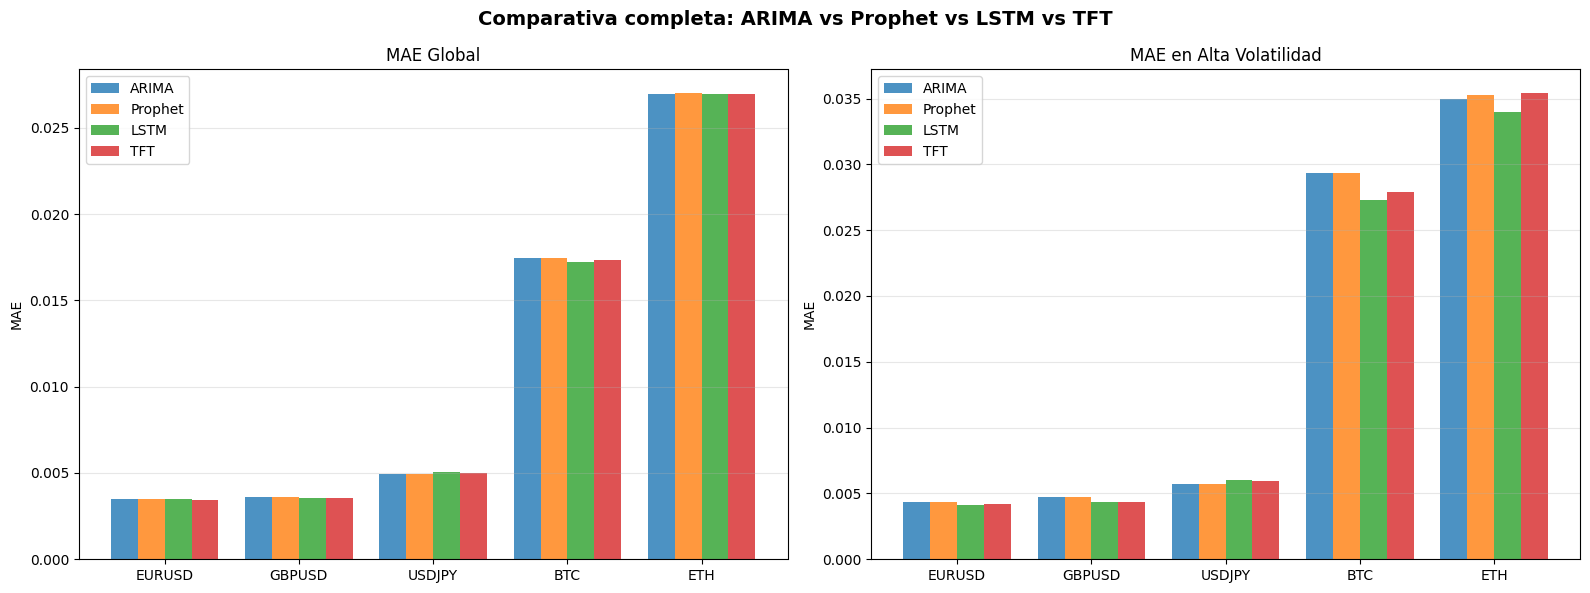

Gráfico guardado en results/06_comparativa_todos_modelos.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Comparativa completa: ARIMA vs Prophet vs LSTM vs TFT", fontsize=14, fontweight="bold")

activos_labels = comparativa["Activo"].values
x = np.arange(len(activos_labels))
width = 0.2

colores = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

# MAE Global
for i, (col, label) in enumerate(zip(["ARIMA_MAE","Prophet_MAE","LSTM_MAE","TFT_MAE"],
                                     ["ARIMA","Prophet","LSTM","TFT"])):
    axes[0].bar(x + (i-1.5)*width, comparativa[col], width, label=label, color=colores[i], alpha=0.8)
    
axes[0].set_title("MAE Global")
axes[0].set_xticks(x)
axes[0].set_xticklabels(activos_labels)
axes[0].set_ylabel("MAE")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# MAE Alta Volatilidad
for i, (col, label) in enumerate(zip(["ARIMA_alta","Prophet_alta","LSTM_alta","TFT_alta"],
                                      ["ARIMA","Prophet","LSTM","TFT"])):
    axes[1].bar(x + (i-1.5)*width, comparativa[col], width, label=label, color=colores[i], alpha=0.8)

axes[1].set_title("MAE en Alta Volatilidad")
axes[1].set_xticks(x)
axes[1].set_xticklabels(activos_labels)
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(RESULTS_PATH / "06_comparativa_todos_modelos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en results/06_comparativa_todos_modelos.png")

## Interpretación visual de la comparativa completa
+ **Convergencia confirmada en Forex:** Tal y como apuntas, el panel izquierdo ratifica el empate técnico en los pares de divisas tradicionales. Las cuatro barras se mantienen exactamente al mismo nivel, evidenciando de forma visual la ineficiencia de aplicar arquitecturas complejas en este mercado. 

+ **Liderazgo del LSTM en Cripto:** En el MAE Global de BTC, la barra roja (TFT) no es la más baja; es la barra verde (LSTM) la que marca el mínimo de error (algo que concuerda con la tabla anterior). Visualmente, el mecanismo de atención del TFT no logra batir a la arquitectura recurrente.

+ **Comportamiento en Alta Volatilidad (Corrección):** El gráfico derecho desmonta la idea de que los modelos clásicos sean mejores bajo estrés en cripto. En BTC, las barras verde y roja (LSTM y TFT) están visiblemente por debajo de las clásicas (azul y naranja), demostrando que el Deep Learning si es más robusto en regímenes extremos. En ETH, el LSTM (verde) vuelve a ser la barra más baja; es únicamente el TFT (rojo) el que sufre un pico de error debido al sobreajuste de sus parámetros. 